Class distribution:
 popularity_class
1    29
0    21
Name: count, dtype: int64
Training set size: (40, 10)
Test set size: (10, 10)
Training classifier...
Model trained successfully!

--- Model Accuracy: 80.00% ---

--- Classification Report ---
                 precision    recall  f1-score   support

 Low Popularity       0.67      0.67      0.67         3
High Popularity       0.86      0.86      0.86         7

       accuracy                           0.80        10
      macro avg       0.76      0.76      0.76        10
   weighted avg       0.80      0.80      0.80        10



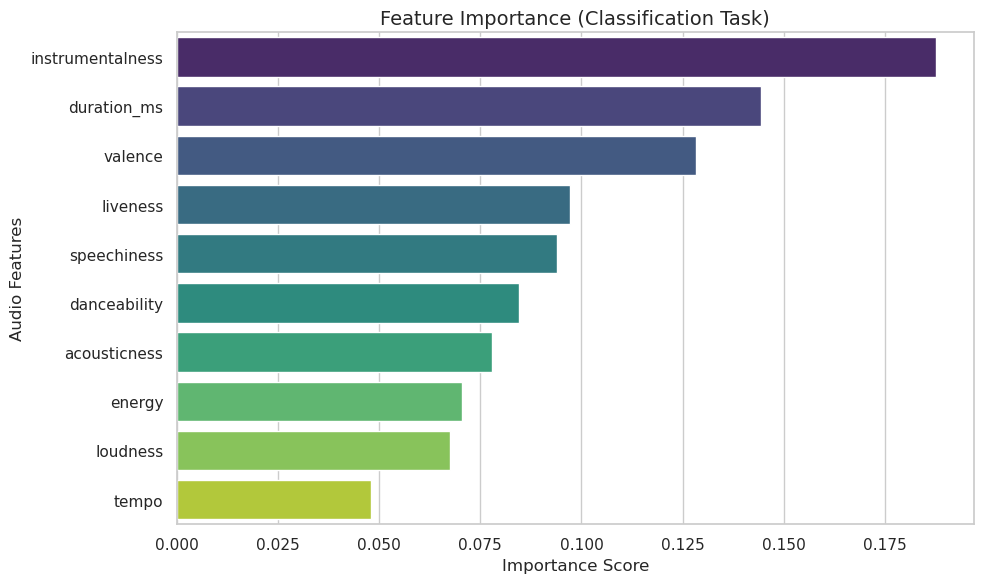

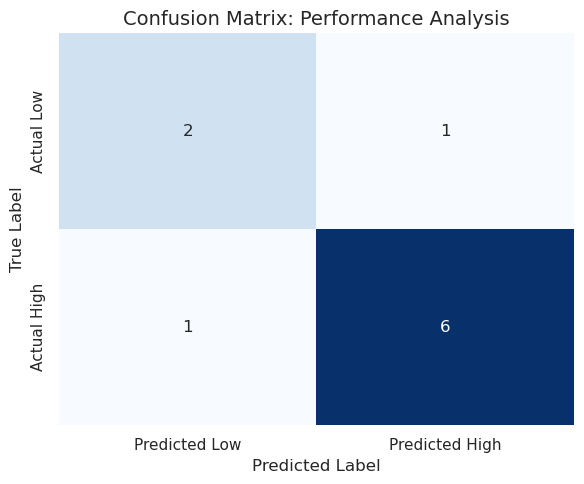

In [1]:
import pandas as pd  # 导入Pandas用于数据处理
import numpy as np  # 导入Numpy用于数值计算
import matplotlib.pyplot as plt  # 导入绘图库
import seaborn as sns  # 导入Seaborn用于美观绘图
from sklearn.model_selection import train_test_split  # 导入数据集划分工具
from sklearn.ensemble import RandomForestClassifier  # 【修改】导入随机森林分类器
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # 【修改】导入分类评估指标

# --- 1. 数据加载与预处理 ---

# 读取数据
df = pd.read_csv('spotify_analysis_dataset.csv')

# 定义特征列 (X)
feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'
]

# 【关键修改】将连续的流行度分数转换为分类标签 (Classification Target)
# 如果流行度 >= 50 分，标记为 1 (High Popularity)
# 如果流行度 < 50 分，标记为 0 (Low Popularity)
threshold = 50
df['popularity_class'] = df['popularity'].apply(lambda x: 1 if x >= threshold else 0)

# 定义新的目标列 y
target_col = 'popularity_class'

# 检查并删除缺失值
df = df.dropna(subset=feature_cols + [target_col])

X = df[feature_cols]
y = df[target_col]

# 查看一下两类数据的数量，看看样本是否均衡
print("Class distribution:\n", y.value_counts())

# --- 2. 划分数据集 ---

#  80% 训练，20% 测试
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# --- 3. 模型训练  ---

# 初始化随机森林分类器
model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training classifier...")
model.fit(X_train, y_train)
print("Model trained successfully!")

# --- 4. 模型评估 ---

# 进行预测
y_pred = model.predict(X_test)

# 计算准确率 (Accuracy)：预测对的比例
acc = accuracy_score(y_test, y_pred)
print(f"\n--- Model Accuracy: {acc:.2%} ---")  # 输出百分比形式

# 打印详细的分类报告 (包含精确率 Precision, 召回率 Recall)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Low Popularity', 'High Popularity']))

# --- 5. 可视化分析 (Visualization) ---

sns.set(style="whitegrid")

# === 图表 1: 特征重要性 ===
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]
y_labels = [feature_names[i] for i in indices]

plt.figure(figsize=(10, 6))
# 使用 hue 解决警告问题
sns.barplot(x=importances[indices], y=y_labels, hue=y_labels, legend=False, palette="viridis")

plt.title('Feature Importance (Classification Task)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Audio Features', fontsize=12)
plt.tight_layout()
plt.show()

# === 图表 2: 混淆矩阵 ===
# 混淆矩阵能展示模型在哪里犯错（例如：把热门错判为冷门）
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
# 绘制热力图
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])

plt.title('Confusion Matrix: Performance Analysis', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()
